In [1]:
import pandas as pd
import requests
from io import StringIO
import yfinance as yf
from datetime import datetime
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
START_ANALYSIS_DATE = pd.Timestamp("2007-02-01")
TODAY = pd.Timestamp.today().normalize()
WIKI_URL = "https://en.wikipedia.org/wiki/Nasdaq-100"

In [5]:
# Fetch HTML from Wikipedia (with User-Agent)
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(WIKI_URL, headers=headers)
response.raise_for_status()
tables = pd.read_html(StringIO(response.text))

In [7]:
# Find the changes table (MultiIndex)
changes_table = None
for tbl in tables:
    if isinstance(tbl.columns, pd.MultiIndex):
        lvl0 = [c[0] for c in tbl.columns]
        if {"Date", "Added", "Removed"}.issubset(set(lvl0)):
            changes_table = tbl.copy()
            break
if changes_table is None:
    raise ValueError("NASDAQ-100 changes table not found.")

In [9]:
# Dynamically select columns
if isinstance(changes_table.columns, pd.MultiIndex):
    date_col = [c for c in changes_table.columns if c[0] == "Date"][0]
    added_col = [c for c in changes_table.columns if c[0] == "Added" and c[1] == "Ticker"][0]
    removed_col = [c for c in changes_table.columns if c[0] == "Removed" and c[1] == "Ticker"][0]
else:
    date_col = [c for c in changes_table.columns if "Date" in str(c)][0]
    added_col = [c for c in changes_table.columns if "Added" in str(c) and "Ticker" in str(c)][0]
    removed_col = [c for c in changes_table.columns if "Removed" in str(c) and "Ticker" in str(c)][0]

changes_table = changes_table[[date_col, added_col, removed_col]].copy()
changes_table.columns = ["date", "added", "removed"]
changes_table["date"] = pd.to_datetime(changes_table["date"])

In [11]:
# Split tickers
def split_tickers(x):
    if pd.isna(x):
        return []
    return [t.strip() for t in str(x).split(",") if t.strip()]

records = []
for _, row in changes_table.iterrows():
    date = row["date"]
    for ticker in split_tickers(row["added"]):
        records.append({"ticker": ticker, "date": date, "action": "added"})
    for ticker in split_tickers(row["removed"]):
        records.append({"ticker": ticker, "date": date, "action": "removed"})

events = pd.DataFrame(records)

In [13]:
# Build start_date / end_date periods
period_records = []

for ticker, group in events.groupby("ticker"):
    group = group.sort_values("date").reset_index(drop=True)
    current_start = None

    for _, row in group.iterrows():
        if row["action"] == "added":
            # start a new period
            current_start = row["date"]
        elif row["action"] == "removed":
            if current_start is None:
                # stock was in the index at the start of analysis
                current_start = START_ANALYSIS_DATE
            # save the period
            period_records.append({
                "ticker": ticker,
                "start_date": current_start,
                "end_date": row["date"]
            })
            current_start = None

    # if the stock is still in the index after the last event
    if current_start is not None:
        period_records.append({
            "ticker": ticker,
            "start_date": current_start,
            "end_date": pd.NaT
        })

df_periods = pd.DataFrame(period_records)

In [15]:
# Limit dates to the analysis period
df_periods = df_periods[
    (df_periods["start_date"] <= TODAY) &
    ((df_periods["end_date"].isna()) | (df_periods["end_date"] >= START_ANALYSIS_DATE))
].copy()
df_periods["start_date"] = df_periods["start_date"].clip(lower=START_ANALYSIS_DATE)
df_periods = df_periods.sort_values(["ticker", "start_date"]).reset_index(drop=True)

In [17]:
# Fill in tickers from Current Components table
current_table = None
for tbl in tables:
    cols = []
    for c in tbl.columns:
        if isinstance(c, tuple):
            cols.append(c[0])
        else:
            cols.append(str(c))
    if "Ticker" in cols and "Company" in cols:
        current_table = tbl.copy()
        break
if current_table is None:
    raise ValueError("NASDAQ-100 Current Components table not found.")

# Extract tickers from Current Components
if isinstance(current_table.columns, pd.MultiIndex):
    ticker_col = [c for c in current_table.columns if c[0] == "Ticker"][0]
    current_table["Ticker"] = current_table[ticker_col]
current_tickers = set(current_table["Ticker"].str.strip())
existing_tickers = set(df_periods["ticker"])
new_tickers = current_tickers - existing_tickers

# Add missing tickers
new_rows = pd.DataFrame([
    {"ticker": t, "start_date": START_ANALYSIS_DATE, "end_date": pd.NaT}
    for t in new_tickers
])
df_periods = pd.concat([df_periods, new_rows], ignore_index=True)
df_periods = df_periods.sort_values(["ticker", "start_date"]).reset_index(drop=True)

In [19]:
# Save final CSV
df_periods.to_csv("nasdaq100_constituents.csv", index=False)
print("✅ Saved: nasdaq100_constituents.csv")
print(f"Number of records (periods): {len(df_periods)}")

✅ Saved: nasdaq100_constituents.csv
Number of records (periods): 310


In [21]:
END_ANALYSIS_DATE = "2025-12-19"
NASDAQ_PERIODS_CSV = "nasdaq100_constituents.csv"
PERCENT_THRESHOLD = 0.75
BATCH_SIZE = 50

In [23]:
# Load periods in which stocks belonged to NASDAQ-100
df_periods = pd.read_csv(NASDAQ_PERIODS_CSV, parse_dates=["start_date", "end_date"])
df_periods["end_date"] = pd.to_datetime(df_periods["end_date"], errors="coerce")

all_tickers = df_periods["ticker"].unique().tolist()

In [25]:
all_tickers

['AAL',
 'AAPL',
 'ABNB',
 'ADBE',
 'ADI',
 'ADP',
 'ADSK',
 'AEOS',
 'AEP',
 'AKAM',
 'ALGN',
 'ALNY',
 'ALTR',
 'ALXN',
 'AMAT',
 'AMD',
 'AMGN',
 'AMLN',
 'AMZN',
 'ANSS',
 'APCC',
 'APOL',
 'APP',
 'ARM',
 'ASML',
 'ATVI',
 'AVGO',
 'AXON',
 'AZN',
 'BATRA',
 'BATRK',
 'BBBY',
 'BEAS',
 'BIDU',
 'BIIB',
 'BKNG',
 'BKR',
 'BMC',
 'BMET',
 'BMRN',
 'BRCM',
 'CA',
 'CCEP',
 'CDNS',
 'CDW',
 'CDWC',
 'CEG',
 'CELG',
 'CEPH',
 'CERN',
 'CHKP',
 'CHRW',
 'CHTR',
 'CKFR',
 'CMCSA',
 'CMCSK',
 'CMVT',
 'COST',
 'CPRT',
 'CRWD',
 'CSCO',
 'CSGP',
 'CSX',
 'CTAS',
 'CTRP',
 'CTRX',
 'CTSH',
 'CTXS',
 'DASH',
 'DDOG',
 'DELL',
 'DISCA',
 'DISCK',
 'DISH',
 'DLTR',
 'DOCU',
 'DTV',
 'DXCM',
 'EA',
 'EBAY',
 'ENDP',
 'ENPH',
 'EQIX',
 'ERIC',
 'ESRX',
 'EXC',
 'EXPD',
 'EXPE',
 'FANG',
 'FAST',
 'FB',
 'FER',
 'FFIV',
 'FI',
 'FLEX',
 'FLIR',
 'FMCN',
 'FOSL',
 'FOX',
 'FOXA',
 'FSLR',
 'FTNT',
 'FWLT',
 'GEHC',
 'GENZ',
 'GFS',
 'GILD',
 'GMCR',
 'GOLD',
 'GOOG',
 'GOOGL',
 'GRMN',
 'HANS',
 '

In [27]:
df_periods

,ticker,start_date,end_date
0,AAL,2014-12-22,2020-04-20
1,AAPL,2007-02-01,NaT
2,ABNB,2021-12-20,NaT
3,ADBE,2007-02-01,NaT
4,ADI,2012-12-24,NaT
...,...,...,...
305,XRAY,2007-02-01,2013-12-23
306,XRAY,2016-06-20,2018-11-19
307,YHOO,2007-02-01,2017-06-19
308,ZM,2020-04-30,2023-12-18


In [29]:
# Check availability of tickers on Yahoo Finance
available_tickers = []
unavailable_tickers = []

for t in all_tickers:
    try:
        info = yf.Ticker(t).info
        if "regularMarketPrice" in info or "previousClose" in info:
            available_tickers.append(t)
        else:
            unavailable_tickers.append(t)
    except:
        unavailable_tickers.append(t)

print(f"Available tickers: {len(available_tickers)}")
print(f"Unavailable tickers (ignored): {len(unavailable_tickers)}")
print(unavailable_tickers)

HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 


Available tickers: 194
Unavailable tickers (ignored): 79
['AEOS', 'ALTR', 'ALXN', 'AMLN', 'ANSS', 'APCC', 'APOL', 'ATVI', 'BEAS', 'BMC', 'BMET', 'BRCM', 'CDWC', 'CELG', 'CEPH', 'CERN', 'CKFR', 'CMCSK', 'CMVT', 'CTRP', 'CTRX', 'CTXS', 'DISCA', 'DISCK', 'DISH', 'DTV', 'ENDP', 'ESRX', 'FLIR', 'FMCN', 'FWLT', 'GENZ', 'GMCR', 'HANS', 'IACI', 'JNPR', 'JOYG', 'KFT', 'KRFT', 'LEAP', 'LIFE', 'LLTC', 'LMCA', 'LMCK', 'LVLT', 'MXIM', 'MYL', 'NDOI', 'NIHD', 'NLOK', 'NLTI', 'NUAN', 'PDCO', 'PETM', 'PPDI', 'QRTEA', 'RIMM', 'SEPR', 'SGEN', 'SHPG', 'SIAL', 'SPLK', 'SPLS', 'STRZA', 'TCFCA', 'TCFCB', 'TLAB', 'UAUA', 'VIAB', 'VIP', 'VMED', 'WBA', 'WCRX', 'WFM', 'WFMI', 'WLTW', 'XLNX', 'XMSR', 'YHOO']


In [31]:
# Download data in batches
def download_in_batches(tickers, start, end, batch_size=50):
    all_data = []
    for i in range(0, len(tickers), batch_size):
        batch = tickers[i:i+batch_size]
        data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
        all_data.append(data)
    if all_data:
        return pd.concat(all_data, axis=1)
    else:
        return pd.DataFrame()

data = download_in_batches(available_tickers, START_ANALYSIS_DATE, END_ANALYSIS_DATE)

C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\4098668450.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
[*********************100%***********************]  50 of 50 completed
C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\4098668450.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
[*********************100%***********************]  50 of 50 completed
C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\4098668450.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
[*********************100%***********************]  50 of 50 completed
C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\4098668450.py:6: FutureWarning: YF.download() has 

In [33]:
data

Ticker            CRWD                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2007-02-01         NaN         NaN         NaN         NaN        NaN   
2007-02-02         NaN         NaN         NaN         NaN        NaN   
2007-02-05         NaN         NaN         NaN         NaN        NaN   
2007-02-06         NaN         NaN         NaN         NaN        NaN   
2007-02-07         NaN         NaN         NaN         NaN        NaN   
...                ...         ...         ...         ...        ...   
2025-12-12  516.409973  517.435974  498.760010  504.779999  2677700.0   
2025-12-15  509.010010  509.010010  487.429993  487.470001  2184900.0   
2025-12-16  486.484009  491.440002  482.000000  488.529999  1758700.0   
2025-12-17  489.410004  490.440002  469.834991  470.019989  2317300.0   
2025-12-18  479.700012  482.040009  473.910004  477.260010  1835100.0   

Ticker          BATRA                                            ...  \
Price            Open       High        Low      Close   Volume  ...   
Date                                                             ...   
2007-02-01        NaN        NaN        NaN        NaN      NaN  ...   
2007-02-02        NaN        NaN        NaN        NaN      NaN  ...   
2007-02-05        NaN        NaN        NaN        NaN      NaN  ...   
2007-02-06        NaN        NaN        NaN        NaN      NaN  ...   
2007-02-07        NaN        NaN        NaN        NaN      NaN  ...   
...               ...        ...        ...        ...      ...  ...   
2025-12-12  43.740002  43.904999  43.200001  43.619999  57000.0  ...   
2025-12-15  43.590000  43.880001  43.430000  43.880001  48100.0  ...   
2025-12-16  43.910000  44.245998  43.560001  43.709999  52600.0  ...   
2025-12-17  43.630001  44.029999  43.549999  43.630001  42700.0  ...   
2025-12-18  43.830002  43.830002  43.270000  43.459999  50900.0  ...   

Ticker            SNPS                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2007-02-01   26.730000   26.900000   26.190001   26.570000  1444000   
2007-02-02   26.570000   26.700001   26.160000   26.389999  1301100   
2007-02-05   26.230000   26.490000   26.160000   26.410000   716200   
2007-02-06   26.620001   26.620001   26.049999   26.260000   770700   
2007-02-07   26.260000   26.840000   26.219999   26.740000  1202600   
...                ...         ...         ...         ...      ...   
2025-12-12  476.239990  477.500000  452.510010  452.950012  2740800   
2025-12-15  458.000000  470.720001  453.489990  454.670013  2634200   
2025-12-16  453.859985  465.000000  452.500000  463.339996  2098700   
2025-12-17  465.910004  467.000000  452.959991  453.070007  2526100   
2025-12-18  460.320007  467.820007  454.690002  458.130005  1694300   

Ticker           XRAY                                            
Price            Open       High        Low      Close   Volume  
Date                                                             
2007-02-01  25.481024  25.579628  25.300250  25.316683   664400  
2007-02-02  25.324892  25.637140  25.242722  25.365978   600500  
2007-02-05  25.234507  25.390631  25.053733  25.275593   498600  
2007-02-06  25.201635  25.596052  25.053728  25.333107   705800  
2007-02-07  26.089073  26.976513  26.047988  26.409536  1971700  
...               ...        ...        ...        ...      ...  
2025-12-12  11.424725  11.621872  11.375437  11.405009  2884800  
2025-12-15  11.523298  11.582443  11.069858  11.237433  4309100  
2025-12-16  11.188147  11.257148  11.010713  11.207861  4745400  
2025-12-17  11.188147  11.365579  11.079715  11.267006  3345100  
2025-12-18  11.355723  11.444438  11.109288  11.119144  2911700  

[4752 rows x 971 columns]

In [35]:
# Create DataFrame with only Close prices
close_data = pd.DataFrame({t: data[t]["Close"] for t in available_tickers if t in data.columns.get_level_values(0)})
close_data = close_data.sort_index()

In [37]:
close_data

,AAL,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,AKAM,ALGN,...,VRTX,WBD,WDAY,WDC,WTW,WYNN,XEL,XRAY,ZM,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2007-02-01,54.669582,2.541442,NaN,38.759998,20.999205,24.181465,44.259998,20.722725,55.509998,16.610001,...,34.799999,7.748257,NaN,11.751137,72.251228,64.261574,11.797513,25.316683,NaN,NaN
2007-02-02,54.660152,2.541741,NaN,38.970001,21.151466,24.430758,44.290001,20.988283,55.549999,16.469999,...,33.730000,7.687978,NaN,11.678598,72.899475,63.843372,11.842763,25.365978,NaN,NaN
2007-02-05,55.065521,2.517448,NaN,38.439999,21.056301,24.485598,44.720001,21.177959,58.180000,16.219999,...,32.520000,7.618424,NaN,11.600014,73.477585,65.350082,11.943342,25.275593,NaN,NaN
2007-02-06,54.971264,2.523746,NaN,38.459999,20.904047,24.331041,43.720001,21.362896,55.150002,16.330000,...,33.090000,7.521049,NaN,11.539565,72.899475,64.582397,12.084148,25.333107,NaN,NaN
2007-02-07,54.754433,2.583729,NaN,38.150002,21.088022,24.306107,42.290001,21.525539,56.950001,16.420000,...,33.080002,7.479317,NaN,11.569794,72.216179,64.462090,12.084148,26.409536,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12,14.960000,278.279999,128.389999,356.429993,279.320007,266.100006,297.640015,114.129997,85.879997,165.429993,...,452.040009,29.980000,224.490005,176.339996,326.028320,123.660004,74.574409,11.405009,89.519997,236.279999
2025-12-15,15.330000,274.109985,131.809998,351.149994,280.440002,264.950012,294.309998,115.769997,86.529999,162.729996,...,455.709991,29.709999,214.899994,172.039993,329.857727,126.250000,75.140045,11.237433,86.540001,230.309998
2025-12-16,15.990000,274.609985,132.009995,347.890015,278.399994,262.170013,293.980011,114.570000,87.739998,162.889999,...,454.959991,28.900000,216.110001,174.580002,328.850555,126.040001,73.165283,11.207861,87.910004,232.779999


In [39]:
# Function to filter stocks active on a given date
def active_tickers_on_date(date):
    mask = (df_periods["start_date"] <= date) & (
        (df_periods["end_date"].isna()) | (df_periods["end_date"] >= date)
    )
    tickers_today = df_periods.loc[mask, "ticker"].unique().tolist()
    # take only tickers available on Yahoo
    return [t for t in tickers_today if t in available_tickers]

In [41]:
# Analyze down days
results = []

for date in close_data.index:
    tickers_today = active_tickers_on_date(date)
    if not tickers_today:
        continue

    closes_today = close_data.loc[date, tickers_today]
    closes_yesterday = close_data.shift(1).loc[date, tickers_today]

    down_today = closes_today < closes_yesterday
    pct_down = down_today.sum() / len(tickers_today)

    if pct_down >= PERCENT_THRESHOLD:
        results.append({"date": date, "pct_down": pct_down})

df_down_days = pd.DataFrame(results)
print(df_down_days.head())
print(f"Number of days when ≥ {int(PERCENT_THRESHOLD*100)}% of stocks declined: {len(df_down_days)}")

        date  pct_down
0 2007-02-09  0.808824
1 2007-02-27  0.884058
2 2007-03-02  0.826087
3 2007-03-13  0.869565
4 2007-03-28  0.753623
Number of days when ≥ 75% of stocks declined: 696


In [43]:
# Forward periods in trading sessions
forward_periods = {
    "1M": 21,    # approx. 21 sessions
    "3M": 63,    # approx. 63 sessions
    "12M": 252   # approx. 252 sessions
}

forward_results = []

for idx, row in df_down_days.iterrows():
    date = row["date"]
    tickers_today = active_tickers_on_date(date)
    if not tickers_today:
        continue

    closes_today = close_data.loc[date, tickers_today]
    closes_yesterday = close_data.shift(1).loc[date, tickers_today]

    down_today = closes_today < closes_yesterday
    against_today = ~down_today

    # index of current date in close_data
    try:
        date_idx = close_data.index.get_loc(date)
    except KeyError:
        continue

    for ticker in tickers_today:
        close_start = closes_today[ticker]
        if np.isnan(close_start):
            continue

        returns = {}
        for period_name, n_sessions in forward_periods.items():
            future_idx = date_idx + n_sessions
            if future_idx < len(close_data.index):
                close_end = close_data.iloc[future_idx][ticker]
                if not np.isnan(close_end):
                    returns[period_name] = (close_end / close_start - 1) * 100
                else:
                    returns[period_name] = np.nan
            else:
                returns[period_name] = np.nan

        forward_results.append({
            "date": date,
            "ticker": ticker,
            "trend": "down" if down_today[ticker] else "against",
            "1M_return": returns["1M"],
            "3M_return": returns["3M"],
            "12M_return": returns["12M"]
        })

df_forward = pd.DataFrame(forward_results)

# Summary
print(df_forward.head())
print(df_forward.groupby("trend")[["1M_return","3M_return","12M_return"]].mean())

        date ticker trend  1M_return  3M_return  12M_return
0 2007-02-09   AAPL  down   6.160724  30.587211   55.458171
1 2007-02-09   ADBE  down   2.574313  10.668791  -10.191083
2 2007-02-09   ADSK  down -10.708327   3.195803   -6.391606
3 2007-02-09   AKAM  down  -8.297721 -18.625355  -39.458689
4 2007-02-09   AMAT  down   2.345039  10.325082    4.112874
         1M_return  3M_return  12M_return
trend                                    
against   1.471366   4.936779   18.122718
down      1.828347   5.531334   20.083428


In [45]:
# Example: GOOG and NDX
tickers = ["GOOG", "^NDX"]
ANALYSIS_DAY = pd.Timestamp("2025-12-22")
START_3M = TODAY - pd.Timedelta(days=108)  # approx. 3 months

data = yf.download(
    tickers,
    start=START_3M,
    end=ANALYSIS_DAY + pd.Timedelta(days=1),
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

In [47]:
returns_from_start = (data / data.iloc[0] - 1) * 100

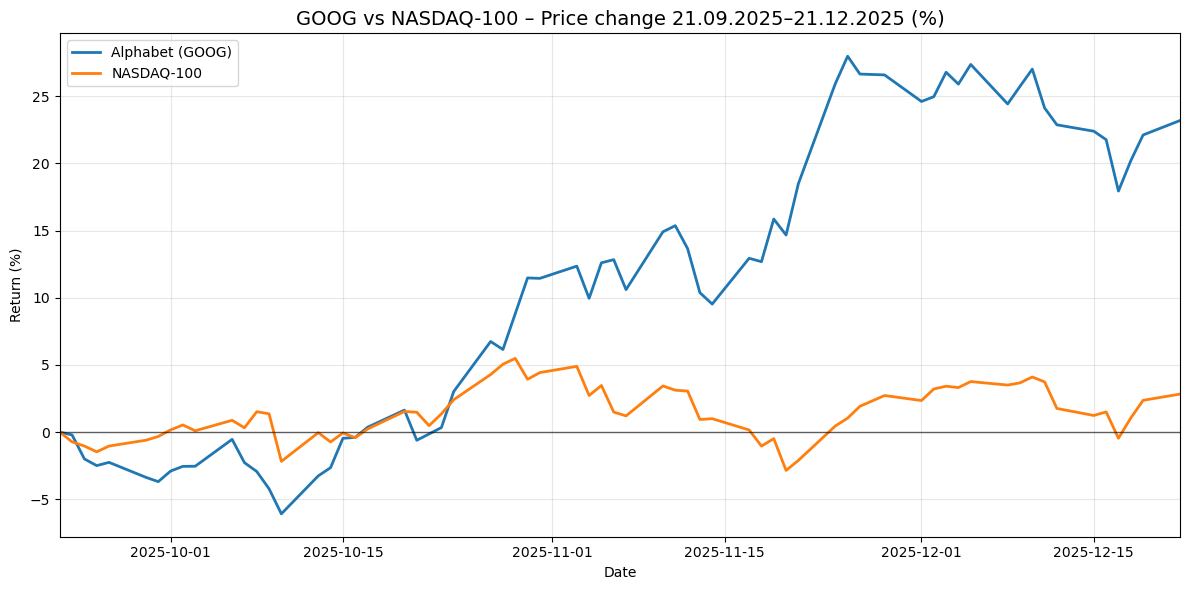

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(
    returns_from_start.index,
    returns_from_start["GOOG"],
    label="Alphabet (GOOG)",
    linewidth=2
)

plt.plot(
    returns_from_start.index,
    returns_from_start["^NDX"],
    label="NASDAQ-100",
    linewidth=2
)

plt.axhline(0, color="black", linewidth=1, alpha=0.6)

plt.title(
    "GOOG vs NASDAQ-100 – Price change 21.09.2025–21.12.2025 (%)",
    fontsize=14
)
plt.ylabel("Return (%)")
plt.xlabel("Date")

plt.xlim(returns_from_start.index.min(), returns_from_start.index.max())

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

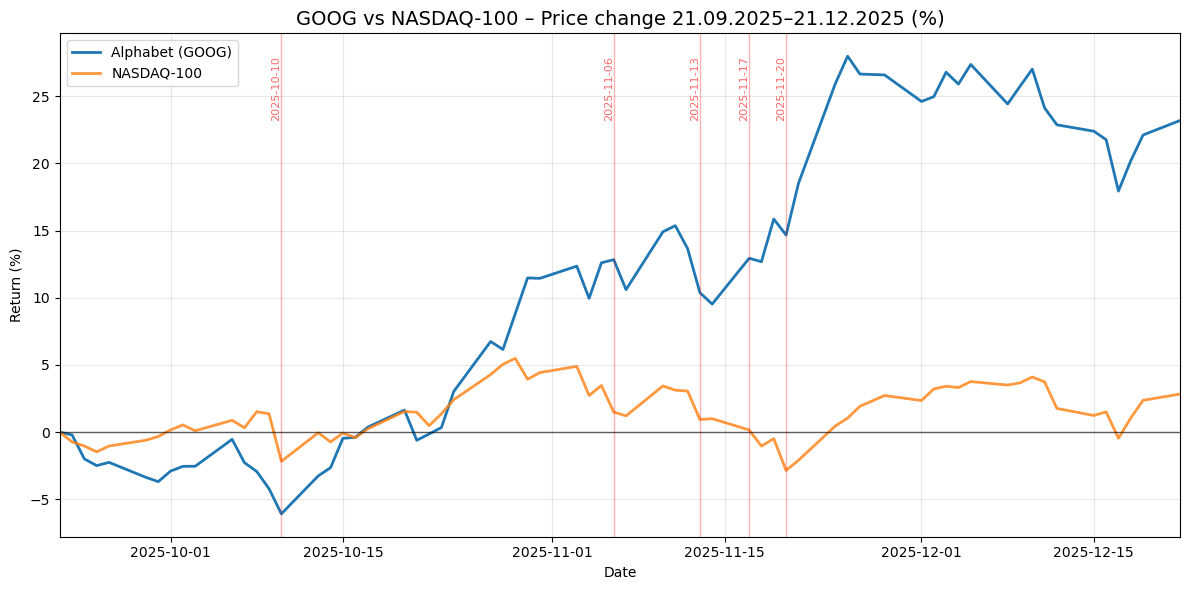

In [51]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    returns_from_start.index,
    returns_from_start["GOOG"],
    label="Alphabet (GOOG)",
    linewidth=2
)

ax.plot(
    returns_from_start.index,
    returns_from_start["^NDX"],
    label="NASDAQ-100",
    linewidth=2,
    alpha=0.8
)

y_top = returns_from_start.max().max()

for d in df_down_days["date"]:
    if d in returns_from_start.index:
        ax.axvline(
            x=d,
            color="red",
            alpha=0.3,
            linewidth=1
        )

        ax.text(
            d,
            y_top,
            d.strftime("%Y-%m-%d"),
            rotation=90,
            fontsize=8,
            color="red",
            alpha=0.6,
            ha="right",
            va="top"
        )

ax.axhline(0, color="black", linewidth=1, alpha=0.6)

ax.set_title(
    "GOOG vs NASDAQ-100 – Price change 21.09.2025–21.12.2025 (%)",
    fontsize=14
)
ax.set_ylabel("Return (%)")
ax.set_xlabel("Date")

ax.set_xlim(
    returns_from_start.index.min(),
    returns_from_start.index.max()
)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [53]:
df_down_days.head(-1)

,date,pct_down
0,2007-02-09,0.808824
1,2007-02-27,0.884058
2,2007-03-02,0.826087
3,2007-03-13,0.869565
4,2007-03-28,0.753623
...,...,...
690,2025-09-02,0.776699
691,2025-10-10,0.873786
692,2025-11-06,0.846154
693,2025-11-13,0.786408


         1M_return_mean  1M_return_median  1M_return_std  \
trend                                                      
against        1.471366          1.252523      11.509455   
down           1.828347          1.817850      11.534422   

         1M_return_<lambda_0>  1M_return_<lambda_1>  3M_return_mean  \
trend                                                                 
against             -4.207996              6.688015        4.936779   
down                -4.284726              7.773327        5.531334   

         3M_return_median  3M_return_std  3M_return_<lambda_0>  \
trend                                                            
against          3.577757      20.551482             -5.988492   
down             4.985908      19.361415             -5.195691   

         3M_return_<lambda_1>  12M_return_mean  12M_return_median  \
trend                                                               
against             13.868323        18.122718          12.959135   
do

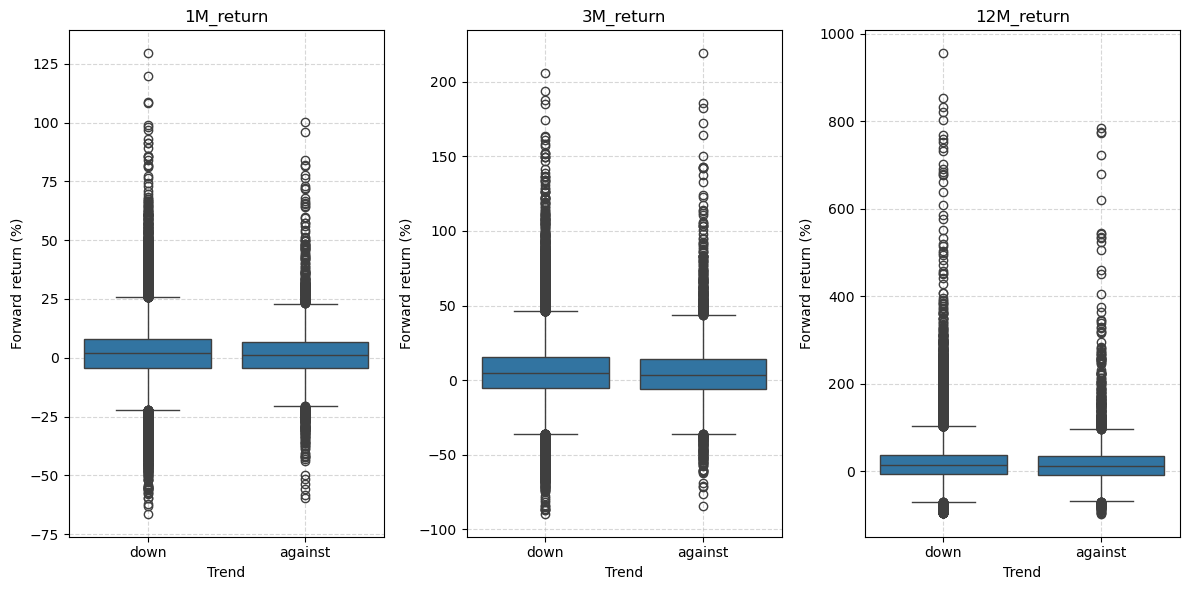

In [55]:
# Aggregation: mean, median, percentiles
summary = df_forward.groupby("trend")[["1M_return","3M_return","12M_return"]].agg(
    ["mean","median","std", lambda x: np.percentile(x.dropna(), 25), lambda x: np.percentile(x.dropna(), 75)]
)
summary.columns = ["_".join(col).strip() for col in summary.columns.values]
print(summary)

# Boxplot for forward returns
plt.figure(figsize=(12,6))

for i, period in enumerate(["1M_return","3M_return","12M_return"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(x="trend", y=period, data=df_forward)
    plt.title(period)
    plt.ylabel("Forward return (%)")
    plt.xlabel("Trend")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [57]:
START_DATE = "2007-02-01"
END_DATE = "2025-12-19"

# Download NASDAQ-100 data
ndx = yf.download(
    "^NDX",
    start=START_DATE,
    end=END_DATE,
    progress=False
)

# Flatten data
ndx_close = ndx["Close"]

if isinstance(ndx_close, pd.DataFrame):
    ndx_close = ndx_close.iloc[:, 0]

ndx_close = ndx_close.dropna()

C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\99012878.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ndx = yf.download(


In [59]:
type(ndx_close)

pandas.core.series.Series

In [61]:
# Forward returns calculated by sessions
forward_periods = {
    "1M": 21,
    "3M": 63,
    "12M": 252
}

ndx_results = []

for i in range(len(ndx_close)):
    start_price = ndx_close.iloc[i]
    date = ndx_close.index[i]

    row = {"date": date}

    for label, n_sessions in forward_periods.items():
        future_idx = i + n_sessions
        if future_idx < len(ndx_close):
            end_price = ndx_close.iloc[future_idx]
            row[f"{label}_return"] = (end_price / start_price - 1) * 100
        else:
            row[f"{label}_return"] = np.nan

    ndx_results.append(row)

df_ndx_forward = pd.DataFrame(ndx_results)

In [63]:
df_ndx_forward

,date,1M_return,3M_return,12M_return
0,2007-02-01,-4.382484,5.815963,3.562481
1,2007-02-02,-3.060403,5.426190,1.705663
2,2007-02-05,-3.302349,5.601565,-1.219792
3,2007-02-06,-2.600582,5.954619,-2.906211
4,2007-02-07,-3.656090,5.229304,-3.183407
...,...,...,...,...
4747,2025-12-12,NaN,NaN,NaN
4748,2025-12-15,NaN,NaN,NaN
4749,2025-12-16,NaN,NaN,NaN
4750,2025-12-17,NaN,NaN,NaN


In [65]:
ndx_stats = df_ndx_forward[["1M_return","3M_return","12M_return"]].agg(
    ["mean", "median", "std",
     lambda x: np.percentile(x.dropna(), 25),
     lambda x: np.percentile(x.dropna(), 75)]
)

ndx_stats.index = ["mean", "median", "std", "p25", "p75"]
print(ndx_stats)

        1M_return  3M_return  12M_return
mean     1.340530   4.069930   16.671506
median   2.000246   5.091069   19.117611
std      5.630160   9.518790   20.546615
p25     -1.525962  -0.403202    5.557060
p75      4.828166   9.511735   29.410121


In [67]:
# Average forward returns by trend
down_vs_against = (
    df_forward
    .groupby("trend")[["1M_return", "3M_return", "12M_return"]]
    .mean()
)

# Add NASDAQ-100 benchmark
benchmark_row = pd.DataFrame(
    [ndx_stats.loc["mean"].values],
    columns=down_vs_against.columns,
    index=["NASDAQ-100"]
)

final_table = pd.concat([benchmark_row, down_vs_against])

# Round to 2 decimals
final_table = final_table.round(2)

print(final_table)

            1M_return  3M_return  12M_return
NASDAQ-100       1.34       4.07       16.67
against          1.47       4.94       18.12
down             1.83       5.53       20.08


In [69]:
# Merge with percent_down info
df_plot = df_forward.merge(
    df_down_days[["date", "pct_down"]],
    on="date",
    how="left"
)

# Convert to %
df_plot["pct_down"] = df_plot["pct_down"] * 100

In [71]:
df_plot

,date,ticker,trend,1M_return,3M_return,12M_return,pct_down
0,2007-02-09,AAPL,down,6.160724,30.587211,55.458171,80.882353
1,2007-02-09,ADBE,down,2.574313,10.668791,-10.191083,80.882353
2,2007-02-09,ADSK,down,-10.708327,3.195803,-6.391606,80.882353
3,2007-02-09,AKAM,down,-8.297721,-18.625355,-39.458689,80.882353
4,2007-02-09,AMAT,down,2.345039,10.325082,4.112874,80.882353
...,...,...,...,...,...,...,...
56157,2025-11-20,VRTX,against,NaN,NaN,NaN,88.349515
56158,2025-11-20,WBD,down,NaN,NaN,NaN,88.349515
56159,2025-11-20,WDAY,down,NaN,NaN,NaN,88.349515
56160,2025-11-20,XEL,down,NaN,NaN,NaN,88.349515


In [73]:
# Extreme cases: ≥95% of stocks down
df_extreme = df_plot[df_plot["pct_down"] >= 95]

summary = df_extreme[["1M_return", "3M_return", "12M_return"]].agg(["mean", "median"])
print(summary)

        1M_return  3M_return  12M_return
mean     1.917646   9.707746   28.990050
median   2.132802   7.911583   22.464238


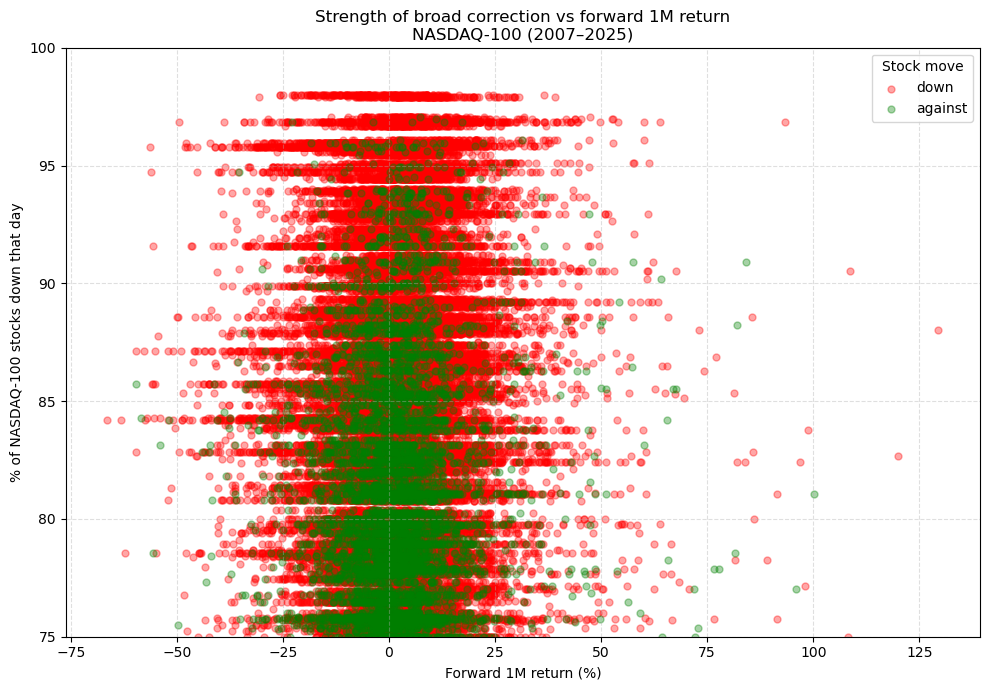

In [77]:
# Scatter plot: forward return vs % of stocks down
color_map = {
    "down": "red",
    "against": "green"
}

plt.figure(figsize=(10, 7))

for trend, color in color_map.items():
    subset = df_plot[df_plot["trend"] == trend]

    plt.scatter(
        subset["1M_return"],
        subset["pct_down"],
        alpha=0.35,
        s=25,
        c=color,
        label=trend
    )

plt.xlabel("Forward 1M return (%)")
plt.ylabel("% of NASDAQ-100 stocks down that day")
plt.title("Strength of broad correction vs forward 1M return\nNASDAQ-100 (2007–2025)")

plt.ylim(75, 100)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Stock move")

plt.tight_layout()
plt.show()

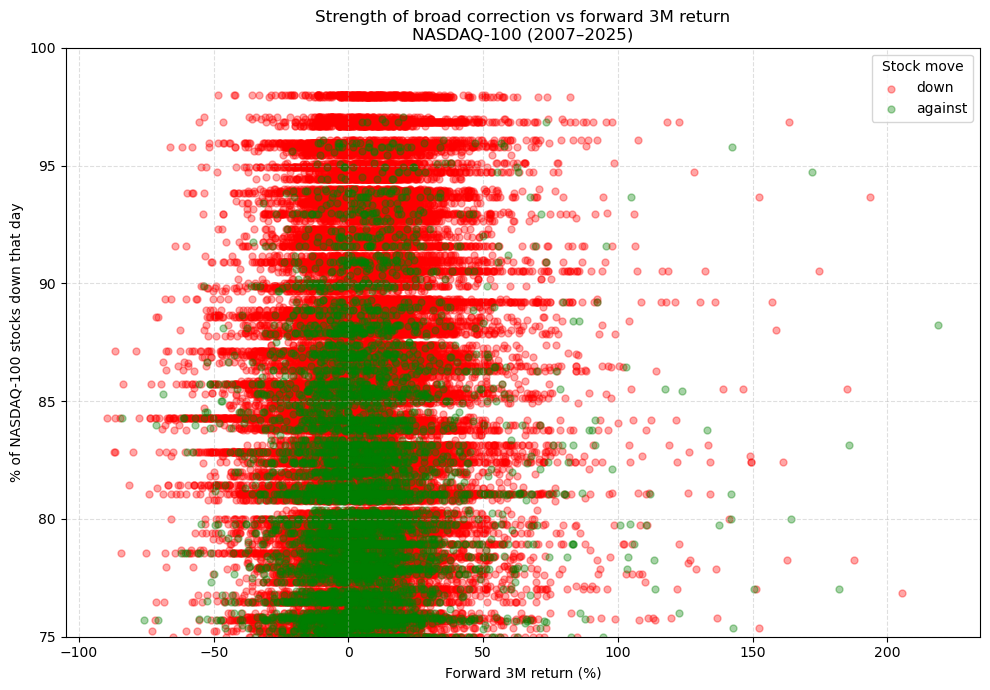

In [83]:
def plot_scatter_forward(df, return_col, title):
    plt.figure(figsize=(10, 7))

    for trend, color in {"down": "red", "against": "green"}.items():
        subset = df[df["trend"] == trend]

        plt.scatter(
            subset[return_col],
            subset["pct_down"],
            alpha=0.35,
            s=25,
            c=color,
            label=trend
        )

    plt.xlabel(f"Forward {return_col.replace('_', ' ')} (%)")
    plt.ylabel("% of NASDAQ-100 stocks down that day")
    plt.title(title)

    plt.ylim(75, 100)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Stock move")

    plt.tight_layout()
    plt.show()

plot_scatter_forward(
    df_plot,
    return_col="3M_return",
    title="Strength of broad correction vs forward 3M return\nNASDAQ-100 (2007–2025)"
)

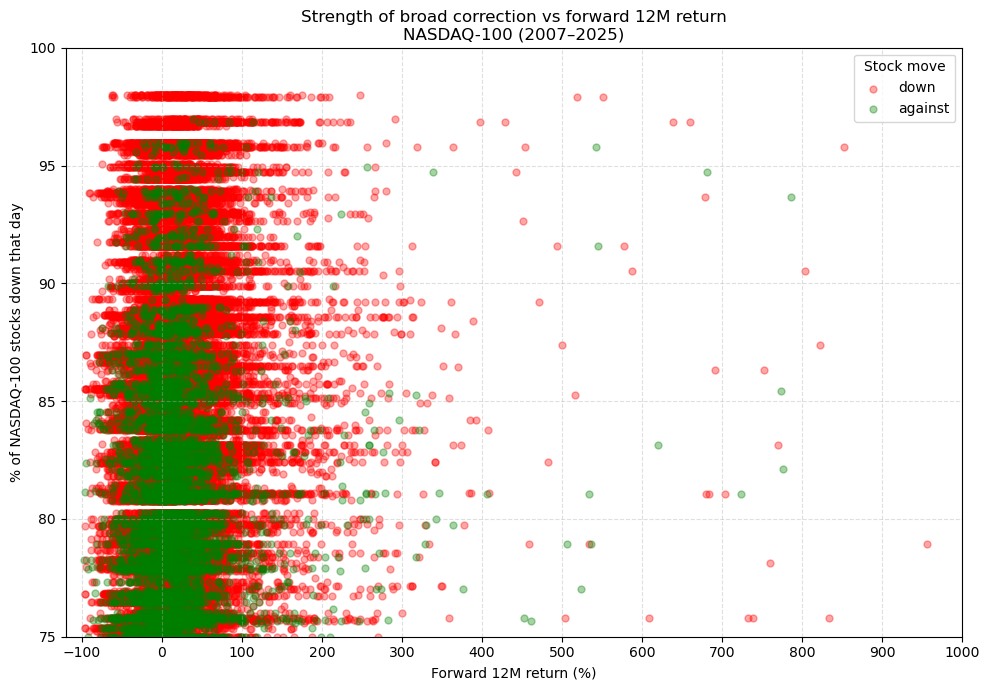

In [87]:
def plot_scatter_forward(df, return_col, title):
    plt.figure(figsize=(10, 7))

    for trend, color in {"down": "red", "against": "green"}.items():
        subset = df[df["trend"] == trend]

        plt.scatter(
            subset[return_col],
            subset["pct_down"],
            alpha=0.35,
            s=25,
            c=color,
            label=trend
        )

    plt.xlabel(f"Forward {return_col.replace('_', ' ')} (%)")
    plt.ylabel("% of NASDAQ-100 stocks down that day")
    plt.title(title)

    # AXES
    plt.xlim(-120, 1000)
    plt.ylim(75, 100)

    # GRID every 100 pp
    plt.xticks(np.arange(-100, 1001, 100))

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Stock move")

    plt.tight_layout()
    plt.show()

plot_scatter_forward(
    df_plot,
    return_col="12M_return",
    title="Strength of broad correction vs forward 12M return\nNASDAQ-100 (2007–2025)"
)

In [89]:
def up_down_stats(df, return_col):
    summary = (
        df
        .assign(
            up=lambda x: x[return_col] > 0
        )
        .groupby("trend")["up"]
        .agg(
            total="count",
            up_cases="sum"
        )
    )

    summary["down_cases"] = summary["total"] - summary["up_cases"]
    summary["up_pct"] = (summary["up_cases"] / summary["total"] * 100).round(2)

    return summary

In [91]:
stats_1M = up_down_stats(df_plot, "1M_return")
print("1M\n", stats_1M)

1M
          total  up_cases  down_cases  up_pct
trend                                       
against   6044      3391        2653   56.11
down     50118     29121       20997   58.10


In [93]:
stats_3M = up_down_stats(df_plot, "3M_return")
print("3M\n", stats_3M)

3M
          total  up_cases  down_cases  up_pct
trend                                       
against   6044      3557        2487   58.85
down     50118     31357       18761   62.57


In [95]:
stats_12M = up_down_stats(df_plot, "12M_return")
print("12M\n", stats_12M)

12M
          total  up_cases  down_cases  up_pct
trend                                       
against   6044      3677        2367   60.84
down     50118     32820       17298   65.49


In [97]:
# Hit rate for all periods
periods = ["1M", "3M", "12M"]
rows = []

for p in periods:
    col = f"{p}_return"
    stats = (
        df_plot
        .assign(up=lambda x: x[col] > 0)
        .groupby("trend")["up"]
        .mean()
        .reset_index()
    )
    stats["period"] = p
    stats["up_pct"] = stats["up"] * 100
    rows.append(stats[["trend", "period", "up_pct"]])

df_hit = pd.concat(rows, ignore_index=True)

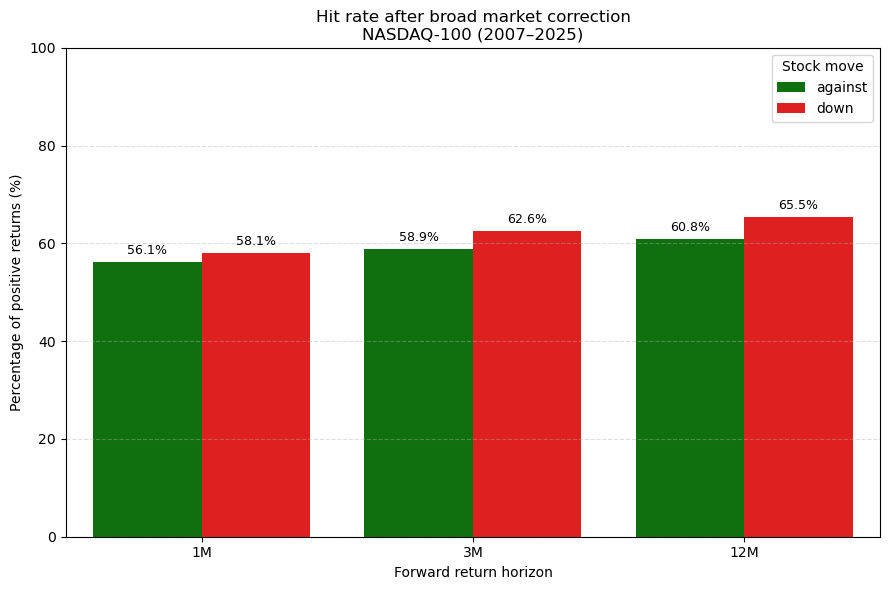

In [101]:
# Bar plot of hit rates
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=df_hit,
    x="period",
    y="up_pct",
    hue="trend",
    palette={"down": "red", "against": "green"}
)

plt.ylabel("Percentage of positive returns (%)")
plt.xlabel("Forward return horizon")
plt.title("Hit rate after broad market correction\nNASDAQ-100 (2007–2025)")

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Stock move")

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 1,  # offset above bar
            s=f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [103]:
df_down_days

,date,pct_down
0,2007-02-09,0.808824
1,2007-02-27,0.884058
2,2007-03-02,0.826087
3,2007-03-13,0.869565
4,2007-03-28,0.753623
...,...,...
691,2025-10-10,0.873786
692,2025-11-06,0.846154
693,2025-11-13,0.786408
694,2025-11-17,0.776699


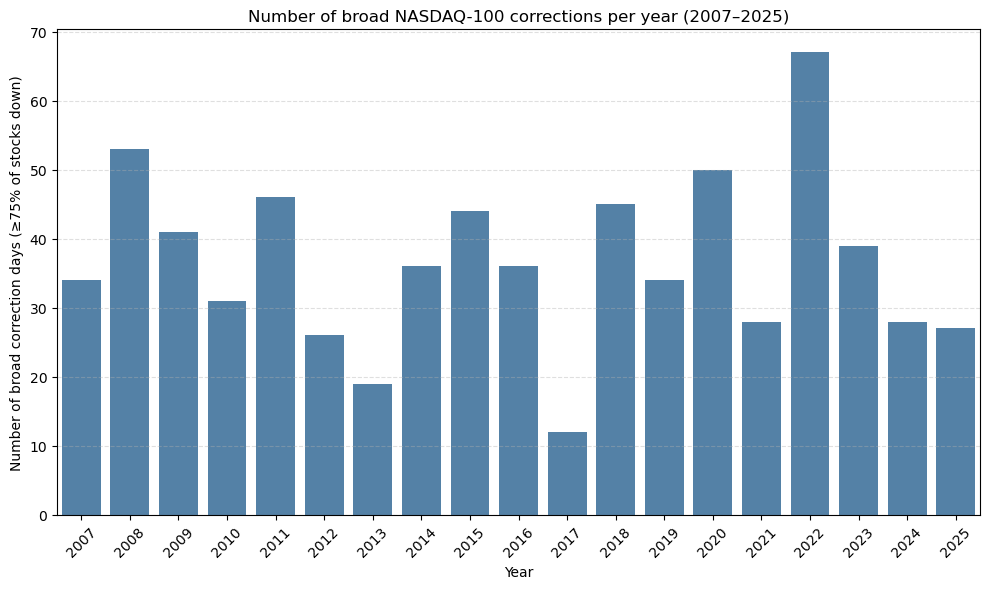

In [105]:
# Extract year from down days
df_down_days["year"] = df_down_days["date"].dt.year

# Count correction days per year
corrections_per_year = df_down_days.groupby("year").size().reset_index(name="num_corrections")

# Bar plot of corrections per year
plt.figure(figsize=(10, 6))
sns.barplot(
    data=corrections_per_year,
    x="year",
    y="num_corrections",
    color="steelblue"
)

plt.xlabel("Year")
plt.ylabel("Number of broad correction days (≥75% of stocks down)")
plt.title("Number of broad NASDAQ-100 corrections per year (2007–2025)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

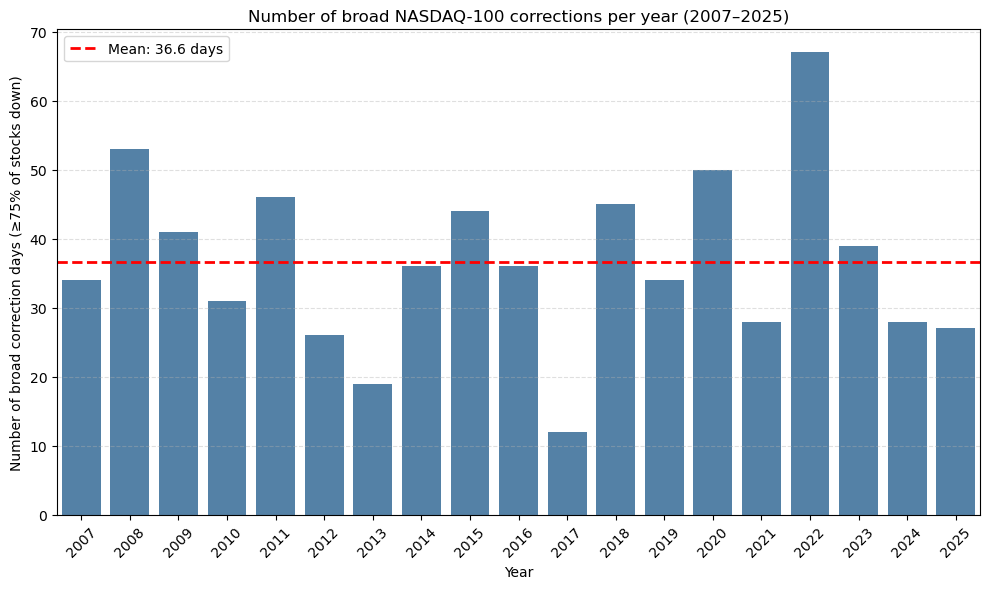

In [107]:
# Mean number of correction days
mean_corrections = corrections_per_year["num_corrections"].mean()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=corrections_per_year,
    x="year",
    y="num_corrections",
    color="steelblue"
)

# Mean line
plt.axhline(
    mean_corrections,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_corrections:.1f} days"
)

plt.xlabel("Year")
plt.ylabel("Number of broad correction days (≥75% of stocks down)")
plt.title("Number of broad NASDAQ-100 corrections per year (2007–2025)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

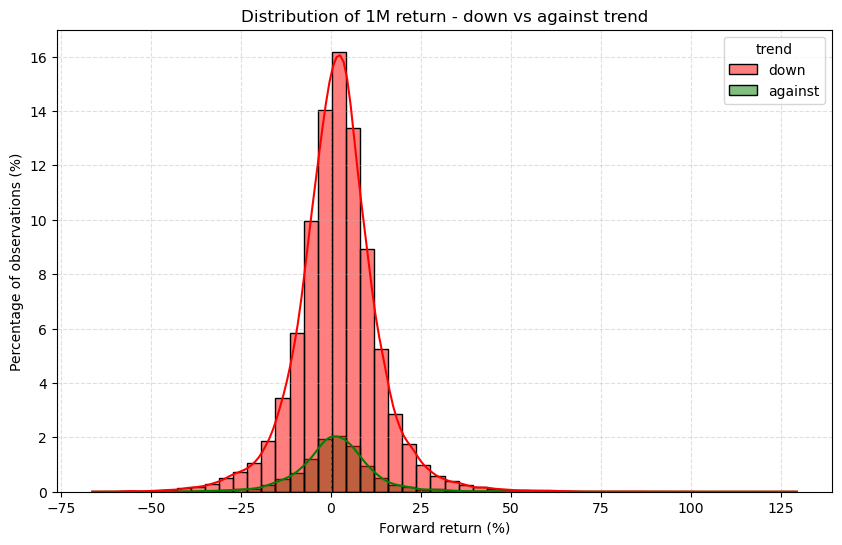

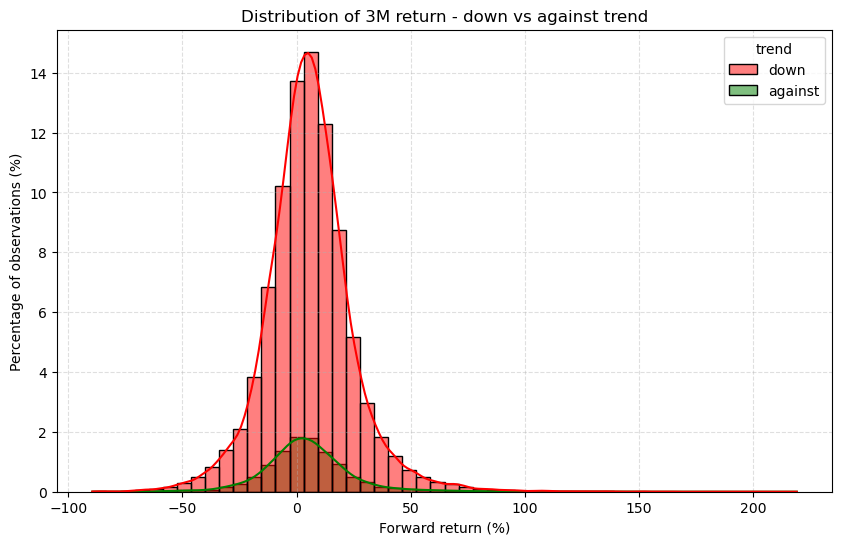

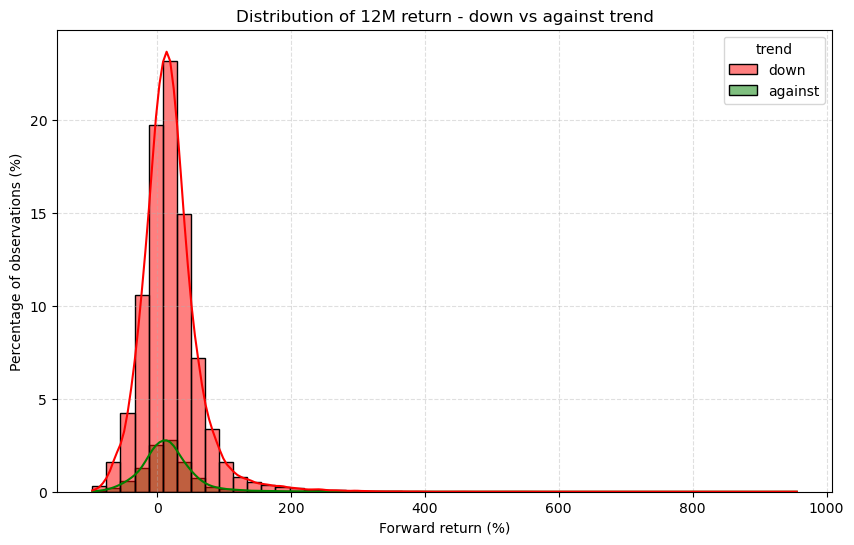

In [109]:
# Forward return histograms
forward_periods = ["1M_return", "3M_return", "12M_return"]

for col in forward_periods:
    plt.figure(figsize=(10,6))
    sns.histplot(
        data=df_plot,
        x=col,
        hue="trend",
        kde=True,
        bins=50,
        palette={"down": "red", "against": "green"},
        alpha=0.5,
        stat="percent"   # <-- percent of observations
    )
    plt.title(f"Distribution of {col.replace('_', ' ')} - down vs against trend")
    plt.xlabel("Forward return (%)")
    plt.ylabel("Percentage of observations (%)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

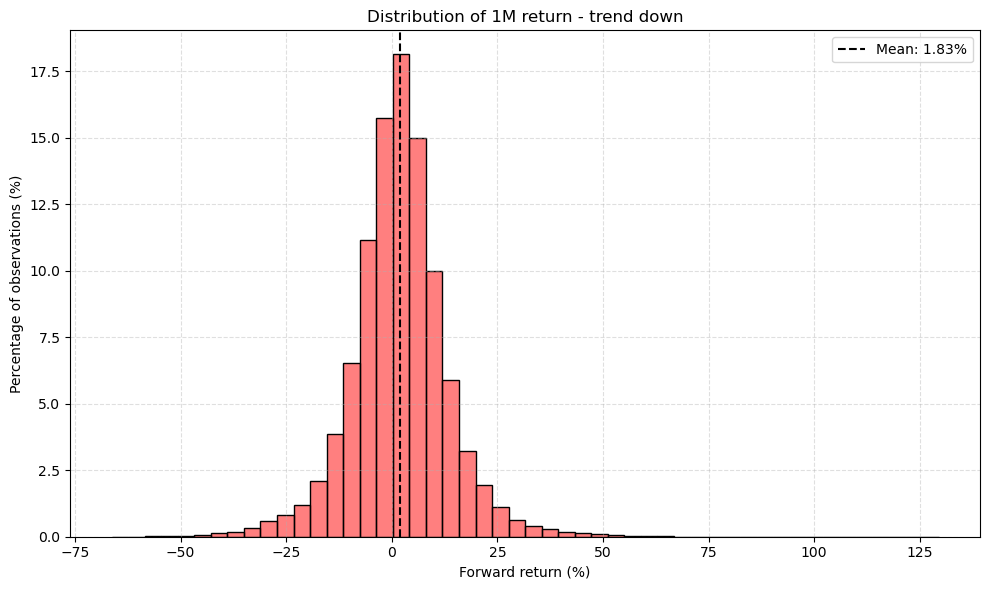

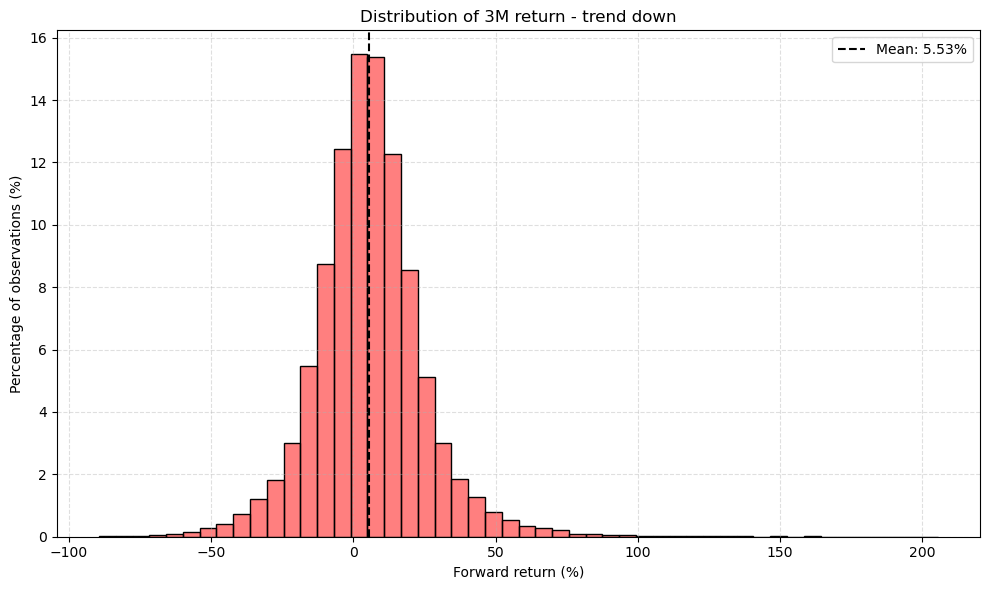

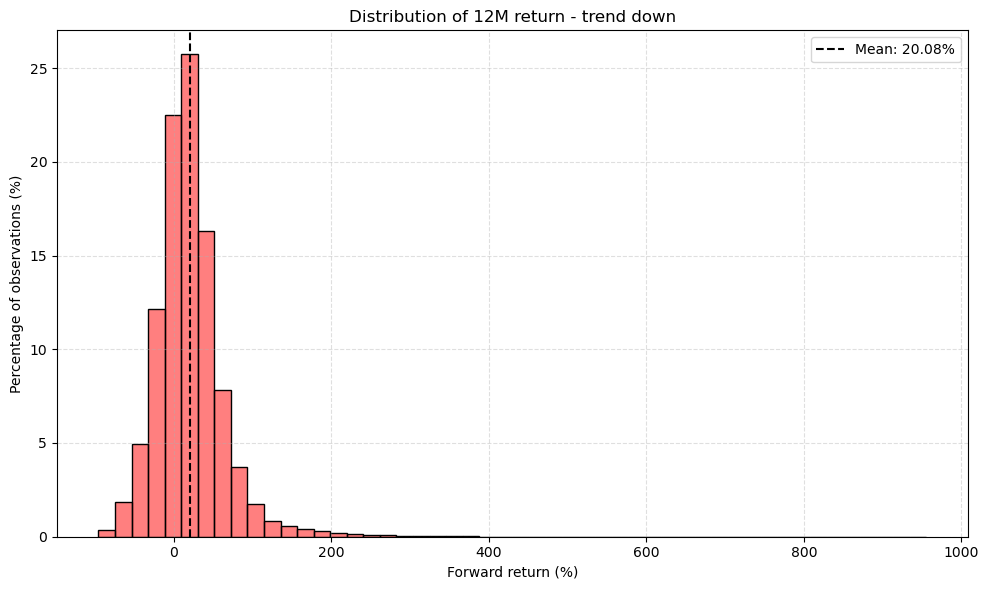

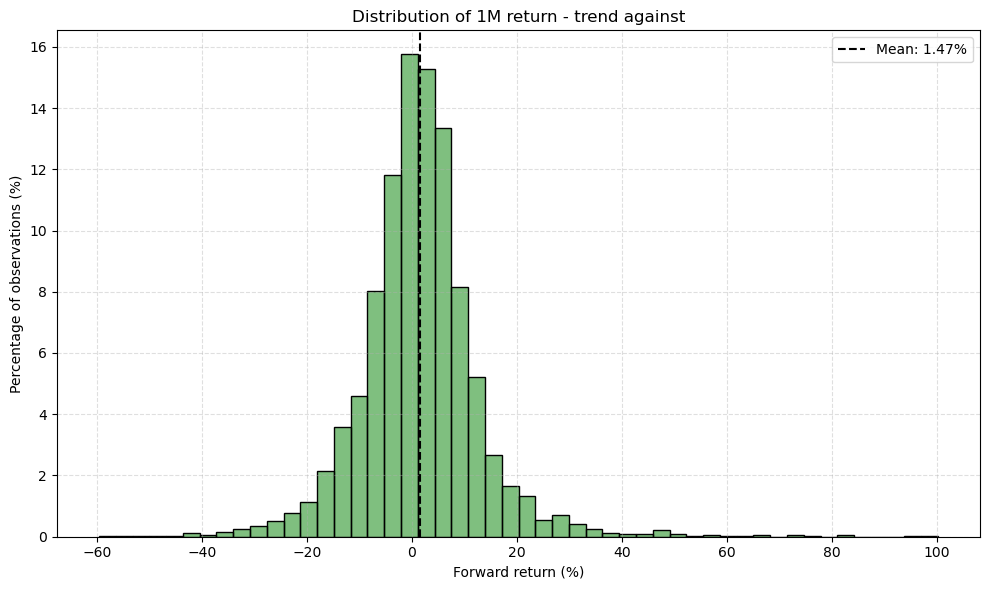

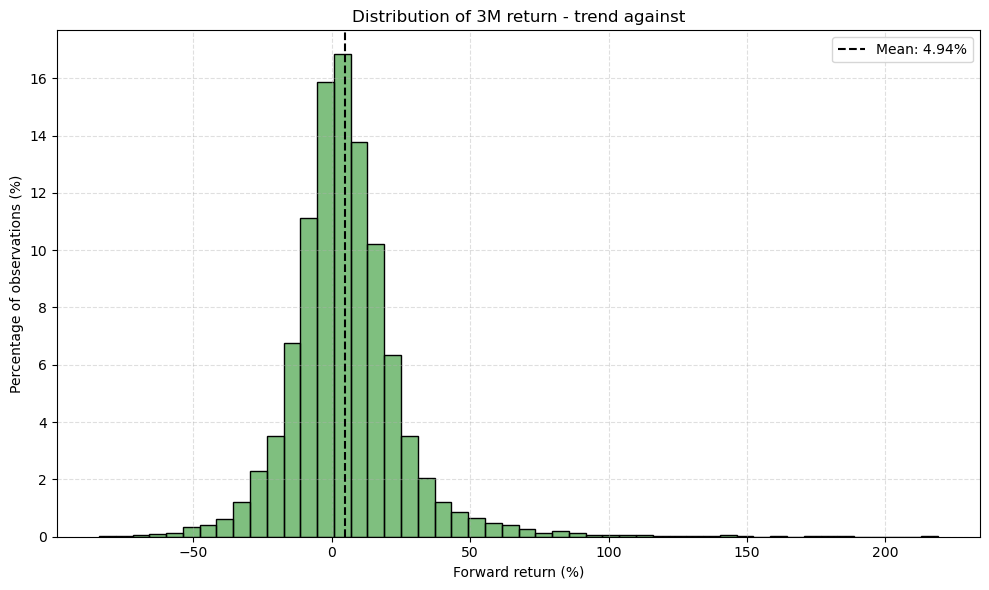

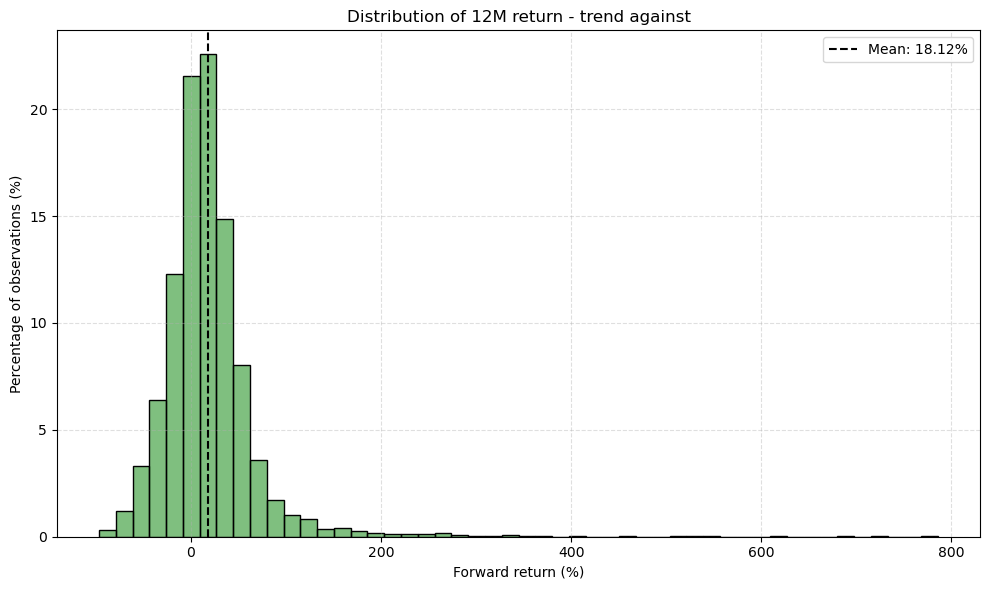

In [111]:
# Trend-specific histograms with mean line
forward_periods = ["1M_return", "3M_return", "12M_return"]
trends = ["down", "against"]

for trend in trends:
    for col in forward_periods:
        plt.figure(figsize=(10,6))
        sns.histplot(
            data=df_plot[df_plot["trend"] == trend],
            x=col,
            kde=False,
            bins=50,
            color="red" if trend=="down" else "green",
            alpha=0.5,
            stat="percent"
        )
        # mean line
        mean_val = df_plot[df_plot["trend"] == trend][col].mean()
        plt.axvline(x=mean_val, color='black', linestyle='--', linewidth=1.5, label=f"Mean: {mean_val:.2f}%")
        
        plt.title(f"Distribution of {col.replace('_',' ')} - trend {trend}")
        plt.xlabel("Forward return (%)")
        plt.ylabel("Percentage of observations (%)")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [113]:
# Define bins for 1M, 3M, 12M forward returns
bins_1M = [-50, -25, 0, 25, 50, np.inf]
labels_1M = ["-50% to -25%", "-25% to 0%", "0% to 25%", "25% to 50%", "> 50%"]

bins_3M = [-75, -50, -25, 0, 25, 50, 75, np.inf]
labels_3M = ["-75% to -50%", "-50% to -25%", "-25% to 0%", "0% to 25%", "25% to 50%", "50% to 75%", "> 75%"]

bins_12M = [-100, -75, -50, -25, 0, 25, 50, 75, 100, np.inf]
labels_12M = ["-100% to -75%", "-75% to -50%", "-50% to -25%", "-25% to 0%",
              "0% to 25%", "25% to 50%", "50% to 75%", "75% to 100%", "> 100%"]

bins_dict = {"1M_return": (bins_1M, labels_1M),
             "3M_return": (bins_3M, labels_3M),
             "12M_return": (bins_12M, labels_12M)}

In [115]:
# Assign bins to df_plot
for col in ["1M_return", "3M_return", "12M_return"]:
    bins, labels = bins_dict[col]
    df_plot[f"{col}_bin"] = pd.cut(df_plot[col], bins=bins, labels=labels, include_lowest=True)

In [117]:
# Prepare histogram data
hist_data = []

for col in ["1M_return", "3M_return", "12M_return"]:
    temp = (
        df_plot.groupby([f"{col}_bin", "trend"])
        .size()
        .reset_index(name="count")
    )
    # percent relative to trend
    temp["percent"] = temp["count"] / temp.groupby("trend")["count"].transform("sum") * 100
    temp["period"] = col
    hist_data.append(temp)

df_hist = pd.concat(hist_data, ignore_index=True)

C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\1443407878.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby([f"{col}_bin", "trend"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\1443407878.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby([f"{col}_bin", "trend"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_17068\1443407878.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_

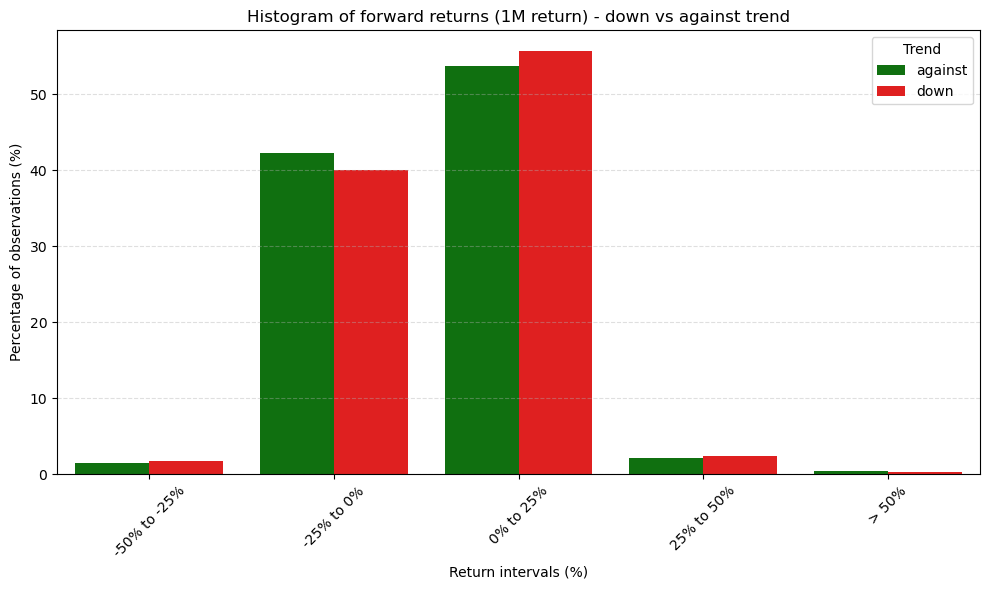

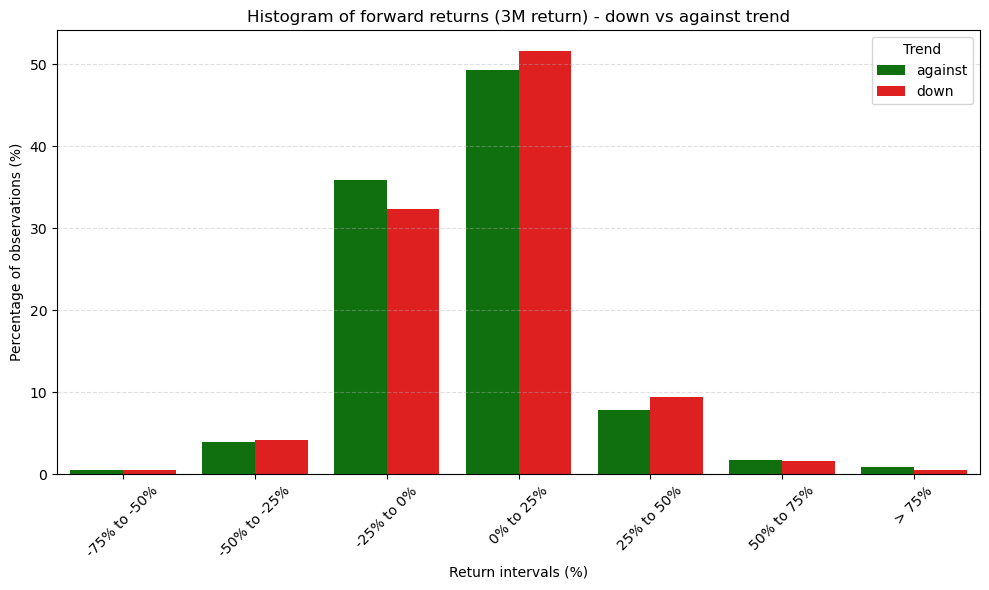

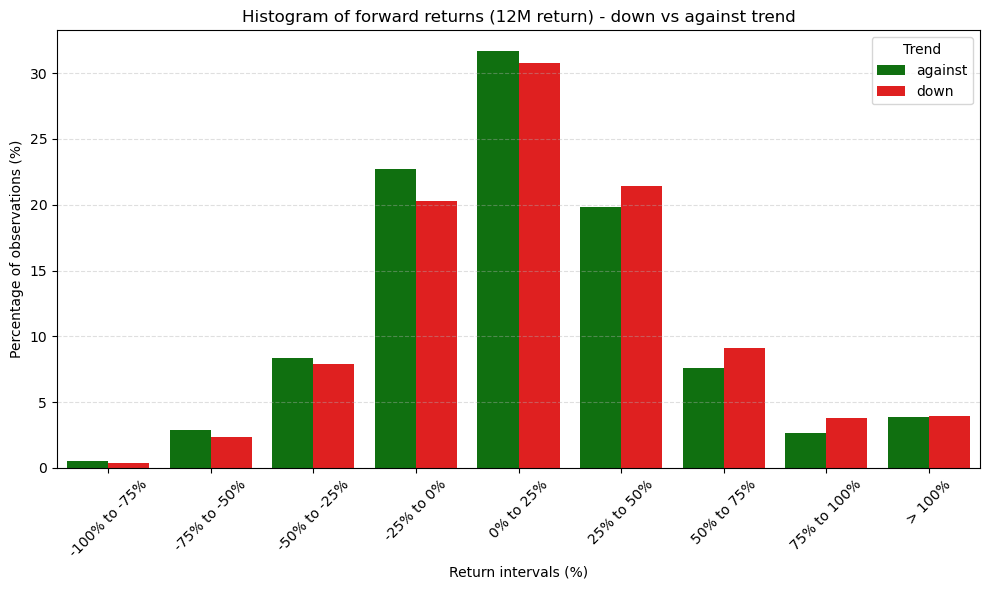

In [119]:
# Plot binned histograms
for col in ["1M_return", "3M_return", "12M_return"]:
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_hist[df_hist["period"]==col],
        x=f"{col}_bin",
        y="percent",
        hue="trend",
        palette={"down": "red", "against": "green"}
    )
    plt.xticks(rotation=45)
    plt.xlabel("Return intervals (%)")
    plt.ylabel("Percentage of observations (%)")
    plt.title(f"Histogram of forward returns ({col.replace('_',' ')}) - down vs against trend")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(title="Trend")
    plt.tight_layout()
    plt.show()